# Ejercicio 1: Limpieza e imputación de un conjunto de datos mixto

In [ ]:
# Importar librerías
import pandas as pd
import numpy as np

# Creación de la base de datos
df = pd.DataFrame({
    'Nombre': ['Ana', 'Luis', 'Pedro', None, 'Marta', 'Luis', 'Sofía'],
    'Edad': [25, np.nan, 35, 29, -5, 25, None],
    'Ciudad': ['Bogotá', 'Medellín', None, 'Medellín', 'Cali', 'Bogotá', 'Cali'],
    'Ingreso': [3500, 4800, np.nan, 5200, 5100, np.nan, 4700],
    'FechaIngreso': ['2023-01-01', '2023-01-05', None, '2023-01-10', '2023-01-12', None, '2023-01-15']
})

# Observar la base de datos para verificar su estructura e identificar datos faltantes
print(df)

# Contar los datos faltantes en cada una de las categorías (solo para saber si es necesario eliminar variables --> no se encuentran variables a eliminar)
df.isnull().sum()


  Nombre  Edad    Ciudad  Ingreso FechaIngreso
0    Ana  25.0    Bogotá   3500.0   2023-01-01
1   Luis   NaN  Medellín   4800.0   2023-01-05
2  Pedro  35.0      None      NaN         None
3   None  29.0  Medellín   5200.0   2023-01-10
4  Marta  -5.0      Cali   5100.0   2023-01-12
5   Luis  25.0    Bogotá      NaN         None
6  Sofía   NaN      Cali   4700.0   2023-01-15


,0
Nombre,1
Edad,2
Ciudad,1
Ingreso,2
FechaIngreso,2


In [ ]:
# Funciones de normalización para nombres de ciudades y fechas
df['Ciudad'] = df['Ciudad'].str.lower()

print(df)

  Nombre  Edad    Ciudad  Ingreso FechaIngreso
0    Ana  25.0    bogotá   3500.0   2023-01-01
1   Luis   NaN  medellín   4800.0   2023-01-05
2  Pedro  35.0      None      NaN         None
3   None  29.0  medellín   5200.0   2023-01-10
4  Marta  -5.0      cali   5100.0   2023-01-12
5   Luis  25.0    bogotá      NaN         None
6  Sofía   NaN      cali   4700.0   2023-01-15


In [ ]:
# Función para quitar acentos de los nombres de las ciudades
import unicodedata

def remove_accents(text):
    if isinstance(text, str):
        return ''.join(c for c in unicodedata.normalize('NFD', text) if unicodedata.category(c) != 'Mn')
    return text

df['Ciudad'] = df['Ciudad'].apply(remove_accents)

print(df)

  Nombre  Edad    Ciudad  Ingreso FechaIngreso
0    Ana  25.0    bogota   3500.0   2023-01-01
1   Luis   NaN  medellin   4800.0   2023-01-05
2  Pedro  35.0      None      NaN         None
3   None  29.0  medellin   5200.0   2023-01-10
4  Marta  -5.0      cali   5100.0   2023-01-12
5   Luis  25.0    bogota      NaN         None
6  Sofía   NaN      cali   4700.0   2023-01-15


In [ ]:
# Convertir None en NaN
df['FechaIngreso'] = df['FechaIngreso'].replace({None: np.nan})
print(df)
print()
df['FechaIngreso'] = df['FechaIngreso'].fillna(pd.to_datetime('1900-01-01'))
# Transformar FechaIngreso a iso
df['FechaIngreso'] = pd.to_datetime(df['FechaIngreso'], errors='coerce')
print(df)

  Nombre  Edad    Ciudad  Ingreso FechaIngreso
0    Ana  25.0    bogota   3500.0   2023-01-01
1   Luis   NaN  medellin   4800.0   2023-01-05
2  Pedro  35.0       NaN      NaN   1900-01-01
3    NaN  29.0  medellin   5200.0   2023-01-10
4  Marta  -5.0      cali   5100.0   2023-01-12
5   Luis  25.0    bogota      NaN   1900-01-01
6  Sofía   NaN      cali   4700.0   2023-01-15

  Nombre  Edad    Ciudad  Ingreso FechaIngreso
0    Ana  25.0    bogota   3500.0   2023-01-01
1   Luis   NaN  medellin   4800.0   2023-01-05
2  Pedro  35.0       NaN      NaN   1900-01-01
3    NaN  29.0  medellin   5200.0   2023-01-10
4  Marta  -5.0      cali   5100.0   2023-01-12
5   Luis  25.0    bogota      NaN   1900-01-01
6  Sofía   NaN      cali   4700.0   2023-01-15


In [ ]:
# Imputación de datos
# Se elimina la observación 2 que es la correspondiente a Pedro porque solo registra datos en 'Edad' y no es suficiente información
df_sin2 = df.drop(2)

# Se reemplaza el nombre de la observación 3 por "desconocido" para que no quede como un dato vacío
df_sin2.loc[3, 'Nombre'] = 'desconocido'

# Reemplazar valores negativos en 'Edad' con NaN para que no afecten el cálculo de la media
df_sin2.loc[df_sin2['Edad'] < 0, 'Edad'] = np.nan

# Calcular la mediana de 'Edad' (excluyendo NaN y el valor negativo que ahora es NaN) y rellenar los valores faltantes
df_sin2['Edad'] = df_sin2['Edad'].fillna(df_sin2['Edad'].median())

# Calcular la mediana de 'Ingreso' y rellenar los valores faltantes
df_sin2['Ingreso'] = df_sin2['Ingreso'].fillna(df_sin2['Ingreso'].median())

# Interpolar la 'FechaIngreso' y rellenar los valores faltantes
df_sin2['FechaIngreso'] = df_sin2['FechaIngreso'].interpolate()

print(df_sin2)

# Al final se observa la matriz sin datos faltantes


        Nombre  Edad    Ciudad  Ingreso FechaIngreso
0          Ana  25.0    bogota   3500.0   2023-01-01
1         Luis  25.0  medellin   4800.0   2023-01-05
3  desconocido  29.0  medellin   5200.0   2023-01-10
4        Marta  25.0      cali   5100.0   2023-01-12
5         Luis  25.0    bogota   4800.0   1900-01-01
6        Sofía  25.0      cali   4700.0   2023-01-15


# Ejercicio 2: Limpieza de duplicados

In [ ]:
# Importar librerías
import pandas as pd
import numpy as np


df = pd.DataFrame({
    'ID': [101, 102, 102, 103, 104, 104, 104],
    'Nombre': ['Ana', 'Luis', 'Luis', 'Marta', 'Carlos', 'Carlos', 'Carlos'],
    'Edad': [25, 30, 30, 29, 40, 40, 41],
    'Ciudad': ['Bogotá', 'Cali', 'Cali', 'Medellín', 'Cali', 'Cali', 'Cali'],
    'FechaRegistro': ['2023-01-01', '2023-01-05', '2023-01-05', '2023-01-10',
                    '2023-01-15', '2023-01-15', '2023-01-16']
})
print(df)

    ID  Nombre  Edad    Ciudad FechaRegistro
0  101     Ana    25    Bogotá    2023-01-01
1  102    Luis    30      Cali    2023-01-05
2  102    Luis    30      Cali    2023-01-05
3  103   Marta    29  Medellín    2023-01-10
4  104  Carlos    40      Cali    2023-01-15
5  104  Carlos    40      Cali    2023-01-15
6  104  Carlos    41      Cali    2023-01-16


In [ ]:
# Total de registros originales = 7

# ¿cuáles y cuántos son los duplicados exactos?
print(df[df.duplicated()])
print('total de duplicados:', df.duplicated().sum())
print()
df.drop_duplicates(inplace=True)
print(df)

    ID  Nombre  Edad Ciudad FechaRegistro
2  102    Luis    30   Cali    2023-01-05
5  104  Carlos    40   Cali    2023-01-15
total de duplicados: 2

    ID  Nombre  Edad    Ciudad FechaRegistro
0  101     Ana    25    Bogotá    2023-01-01
1  102    Luis    30      Cali    2023-01-05
3  103   Marta    29  Medellín    2023-01-10
4  104  Carlos    40      Cali    2023-01-15
6  104  Carlos    41      Cali    2023-01-16


- ¿Cuáles y cuántos son los duplicados por varias columnas?

  si analizamos las columnas "Nombre" y "Edad" se evidencia que no hay duplicados, sin embargo, cuando se comparan "Nombre" y "Ciudad" se encuentra que siguen existiendo duplicados, entonces, se podrían seguir eliminando duplicados, pero en este caso solo nos interesa eliminar los duplicados completos.


- ¿Cuántos registros debes eliminar?

  Se deben eliminar 2 registros que son los duplicados completos.


- ¿Cuántos registros quedan después de la limpieza?

  Después de la limpieza donde se eliminan 2 registros quedan en total 5 registros.

# Ejercicio 3: Corrección de errores tipográficos o de codificación

In [ ]:
# Importar librerías
import pandas as pd
import numpy as np

df = pd.DataFrame({
    'Ciudad': ['bogota', 'Bogotá', 'BOGOTA', 'bogotá', 'bogata', 'Bógota', 'BogoTa', 'Cali', 'calí', 'medellín', 'medellin']
})

# Estandarización de la variable ciudad


In [ ]:
# Estandarización: Convertir a minúsculas y quitar acentos (ya aplicado en celdas anteriores)
df['Ciudad'] = df['Ciudad'].str.lower()
import unicodedata
def remove_accents(text):
    if isinstance(text, str):
        return ''.join(c for c in unicodedata.normalize('NFD', text) if unicodedata.category(c) != 'Mn')
    return text
df['Ciudad'] = df['Ciudad'].apply(remove_accents)

# Mapeo para corregir errores tipográficos
# Definir un diccionario para correcciones comunes

from difflib import get_close_matches
# Diccionario de ciudades
diccionario = ['bogota', 'medellin', 'cali']

for x in diccionario:
  matches = get_close_matches(x, df['Ciudad'], n=20)
  print(matches)
  df.replace(matches, x, inplace=True)

print()
print(df)


['bogota', 'bogota', 'bogota', 'bogota', 'bogota', 'bogota', 'bogata']
['medellin', 'medellin']
['cali', 'cali']

      Ciudad
0     bogota
1     bogota
2     bogota
3     bogota
4     bogota
5     bogota
6     bogota
7       cali
8       cali
9   medellin
10  medellin


# Ejercicio 4: Identificación de mecanismos de datos faltantes (MCAR, MAR, MNAR)

Se tiene una base de datos de estudiantes universitarios con las siguientes variables: , Edad, Género, Promedio académico, Ingreso familiar y Horas de estudio por semana. Sin embargo, hay valores faltantes en algunas variables. En los siguientes escenarios, clasifica el tipo de dato faltante (MCAR, MAR o MNAR) y justifica tu respuesta en máximo 2 líneas.
- Escenario 1. Al analizar los datos, se observa que los valores faltantes en Ingreso familiar aparecen de forma completamente aleatoria, sin relación con ninguna otra variable (ni edad, ni género, ni promedio, etc.).

  R/= MCAR, debio a que es aleatoria y no tiene relación con las otras variables

- Escenario 2. Se detecta que los valores faltantes en Horas de estudio ocurren principalmente en estudiantes con promedios bajos.

  R/= MAR, debido a que la probabilidad de la falta del dato depende de otras variables observadas como el promedio.

- Escenario 3. Se detecta que los valores faltantes en Horas de estudio ocurren principalmente en estudiantes con promedios bajos.

  R/= MAR, debido a que la probabilidad de la falta del dato depende de otras variables observadas como el promedio.

- Escenario 4. Se observa que los valores faltantes en Promedio académico aparecen con mayor frecuencia en estudiantes de cierto género.

  R/= MAR, debido a que la probabilidad de la falta del dato depende de otras variables observadas como el promedio.

- Escenario 5. Algunos estudiantes con muy pocas horas de estudio no reportan esta variable porque consideran que el valor es “demasiado bajo” para registrarlo.

  R/= MNAR, su falta depende de el propio valor faltante y no se realaciona con otras.

# Ejercicio 5: Imputación con KNN y regresión

In [2]:
# Crear el dataframe
import pandas as pd
import numpy as np

np.random.seed(42)

n = 30

df = pd.DataFrame({
    'Edad': np.random.randint(18, 60, n),
    'Promedio': np.round(np.random.uniform(2.0, 5.0, n), 2),
    'Horas_estudio': np.random.randint(0, 40, n),
    'Ingreso_familiar': np.random.randint(800000, 8000000, n),
    'Semestres_cursados': np.random.randint(1, 10, n)
})

# Introducción de valores faltantes con distintos patrones
df.loc[[2, 5, 8, 15], 'Promedio'] = np.nan
df.loc[[1, 7, 10, 18], 'Horas_estudio'] = np.nan
df.loc[[3, 6, 14], 'Ingreso_familiar'] = np.nan

# Visualización del dataframe
print(df)

    Edad  Promedio  Horas_estudio  Ingreso_familiar  Semestres_cursados
0     56      2.70           35.0         2909818.0                   7
1     46      2.27            NaN         3031785.0                   7
2     32       NaN           30.0         5283302.0                   9
3     25      3.15           14.0               NaN                   3
4     38      4.95            7.0         3525928.0                   7
5     56       NaN           13.0         4653339.0                   1
6     36      4.58           22.0               NaN                   4
7     40      4.04            NaN         1879111.0                   4
8     28       NaN           20.0         1796107.0                   5
9     28      2.04           15.0         4321441.0                   7
10    41      4.83            NaN         7930144.0                   7
11    53      3.69           23.0         5345583.0                   4
12    57      3.16           25.0         2670230.0             

In [3]:
# Proporción de datos
missing_data_proportion = df.isnull().sum() / len(df)
print("Proporción de datos faltantes por variable:")
print(missing_data_proportion)

Proporción de datos faltantes por variable:
Edad                  0.000000
Promedio              0.133333
Horas_estudio         0.133333
Ingreso_familiar      0.100000
Semestres_cursados    0.000000
dtype: float64


- ¿Qué variables tienen mayor proporción de datos faltantes?
  
  R/= El promedio y las horas de estudio tienen la mayor proporción de datos faltantes

- ¿Observas algún patrón estructurado o parecen aleatorios?

  R/= Observando los datos se concluye que es aleatorio debido a que no se encuentra relación entre los datos faltantes y otras variables.

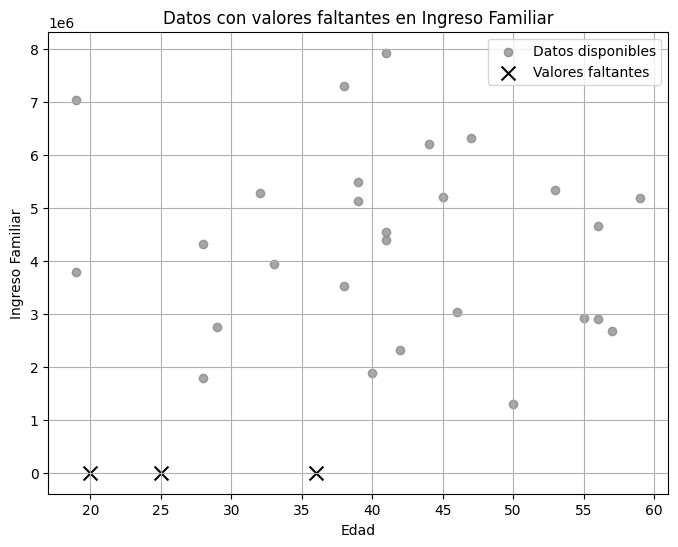

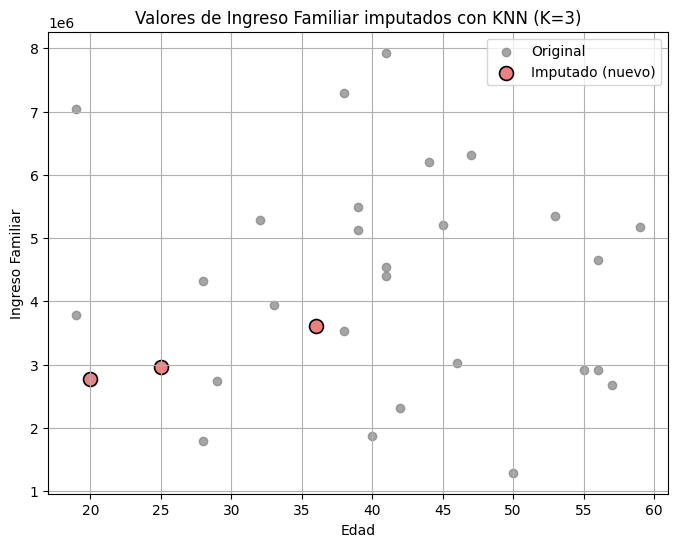

Valores faltantes antes de imputar:
Edad                  0
Promedio              4
Horas_estudio         4
Ingreso_familiar      3
Semestres_cursados    0
dtype: int64

Valores faltantes después de imputar:
Edad                  0
Promedio              0
Horas_estudio         0
Ingreso_familiar      0
Semestres_cursados    0
dtype: int64


In [7]:
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt


# Imputación con KNN
imputer = KNNImputer(n_neighbors=3)
data_imputed = pd.DataFrame(imputer.fit_transform(df),
                            columns=df.columns)

# -------- Máscara de valores imputados --------
mask_missing_ingreso = df["Ingreso_familiar"].isnull()

# figure
plt.figure(figsize=(8,6))
plt.scatter(df["Edad"], df["Ingreso_familiar"],
            color="gray", alpha=0.7, label="Datos disponibles")
plt.scatter(df.loc[mask_missing_ingreso, "Edad"],
            [0]*mask_missing_ingreso.sum(),
            marker="x", color="black", s=100, label="Valores faltantes")

plt.xlabel("Edad")
plt.ylabel("Ingreso Familiar")
plt.title("Datos con valores faltantes en Ingreso Familiar")
plt.legend()
plt.grid(True)
plt.show()

# figure
plt.figure(figsize=(8,6))
plt.scatter(data_imputed.loc[~mask_missing_ingreso, "Edad"],
            data_imputed.loc[~mask_missing_ingreso, "Ingreso_familiar"],
            color="gray", alpha=0.7, label="Original")
plt.scatter(data_imputed.loc[mask_missing_ingreso, "Edad"],
            data_imputed.loc[mask_missing_ingreso, "Ingreso_familiar"],
            color="lightcoral", edgecolors="black", linewidths=1.2,
            s=100, label="Imputado (nuevo)")

plt.xlabel("Edad")
plt.ylabel("Ingreso Familiar")
plt.title("Valores de Ingreso Familiar imputados con KNN (K=3)")
plt.legend()
plt.grid(True)
plt.show()

# -------- Verificación --------
print("Valores faltantes antes de imputar:")
print(df.isnull().sum())

print("\nValores faltantes después de imputar:")
print(data_imputed.isnull().sum())

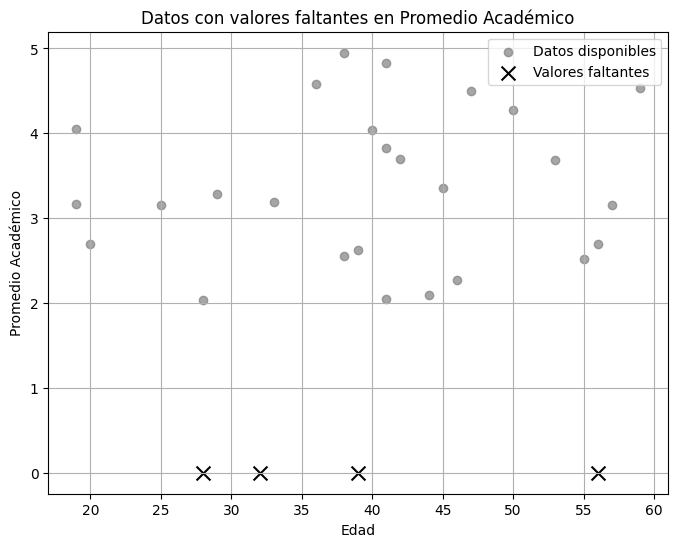

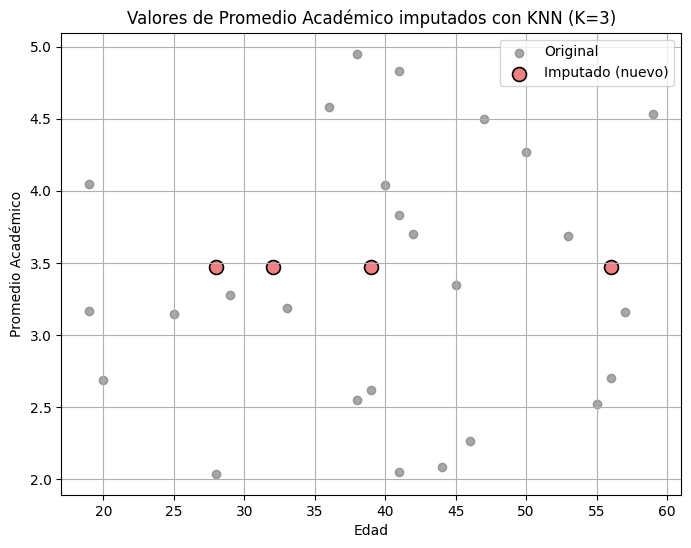

In [8]:
# -------- Máscara de valores imputados para 'Promedio' --------
mask_missing_promedio = df["Promedio"].isnull()

# figure: Datos con valores faltantes en Promedio
plt.figure(figsize=(8,6))
plt.scatter(df["Edad"], df["Promedio"],
            color="gray", alpha=0.7, label="Datos disponibles")
plt.scatter(df.loc[mask_missing_promedio, "Edad"],
            [0]*mask_missing_promedio.sum(),
            marker="x", color="black", s=100, label="Valores faltantes")

plt.xlabel("Edad")
plt.ylabel("Promedio Académico")
plt.title("Datos con valores faltantes en Promedio Académico")
plt.legend()
plt.grid(True)
plt.show()

# figure: Valores de Promedio imputados con KNN
plt.figure(figsize=(8,6))
plt.scatter(data_imputed.loc[~mask_missing_promedio, "Edad"],
            data_imputed.loc[~mask_missing_promedio, "Promedio"],
            color="gray", alpha=0.7, label="Original")
plt.scatter(data_imputed.loc[mask_missing_promedio, "Edad"],
            data_imputed.loc[mask_missing_promedio, "Promedio"],
            color="lightcoral", edgecolors="black", linewidths=1.2,
            s=100, label="Imputado (nuevo)")

plt.xlabel("Edad")
plt.ylabel("Promedio Académico")
plt.title("Valores de Promedio Académico imputados con KNN (K=3)")
plt.legend()
plt.grid(True)
plt.show()

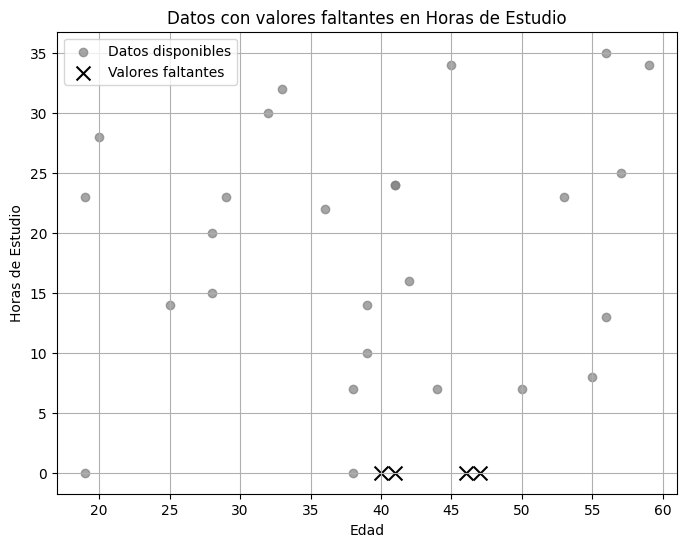

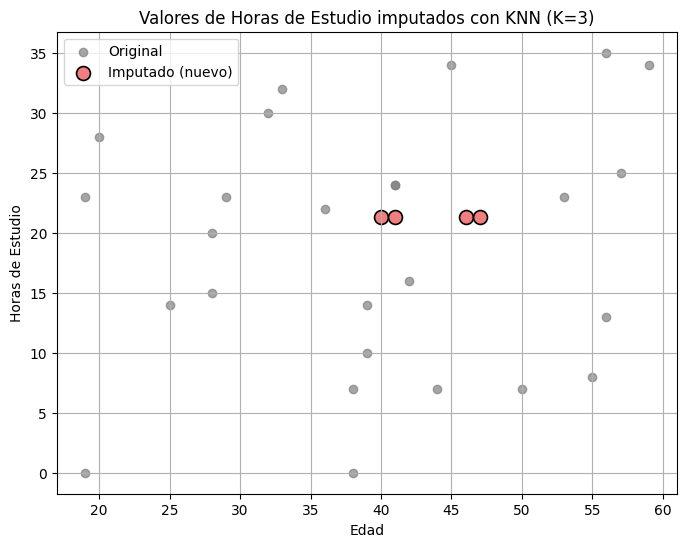

In [9]:
# -------- Máscara de valores imputados para 'Horas_estudio' --------
mask_missing_horas = df["Horas_estudio"].isnull()

# figure: Datos con valores faltantes en Horas de Estudio
plt.figure(figsize=(8,6))
plt.scatter(df["Edad"], df["Horas_estudio"],
            color="gray", alpha=0.7, label="Datos disponibles")
plt.scatter(df.loc[mask_missing_horas, "Edad"],
            [0]*mask_missing_horas.sum(),
            marker="x", color="black", s=100, label="Valores faltantes")

plt.xlabel("Edad")
plt.ylabel("Horas de Estudio")
plt.title("Datos con valores faltantes en Horas de Estudio")
plt.legend()
plt.grid(True)
plt.show()

# figure: Valores de Horas de Estudio imputados con KNN
plt.figure(figsize=(8,6))
plt.scatter(data_imputed.loc[~mask_missing_horas, "Edad"],
            data_imputed.loc[~mask_missing_horas, "Horas_estudio"],
            color="gray", alpha=0.7, label="Original")
plt.scatter(data_imputed.loc[mask_missing_horas, "Edad"],
            data_imputed.loc[mask_missing_horas, "Horas_estudio"],
            color="lightcoral", edgecolors="black", linewidths=1.2,
            s=100, label="Imputado (nuevo)")

plt.xlabel("Edad")
plt.ylabel("Horas de Estudio")
plt.title("Valores de Horas de Estudio imputados con KNN (K=3)")
plt.legend()
plt.grid(True)
plt.show()

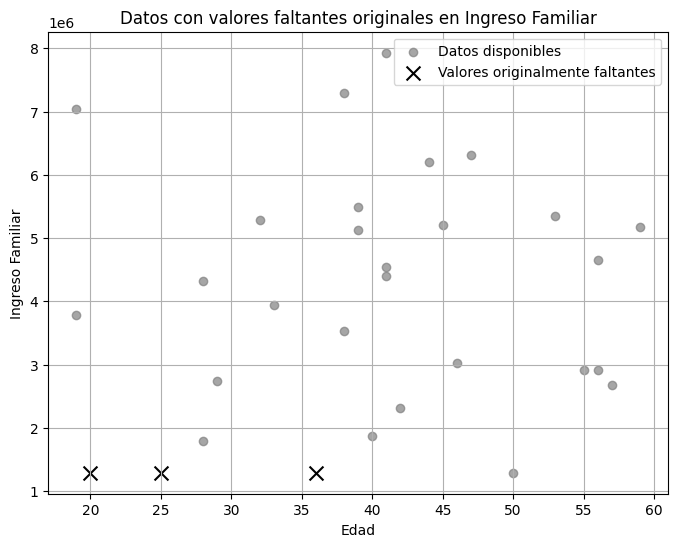

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


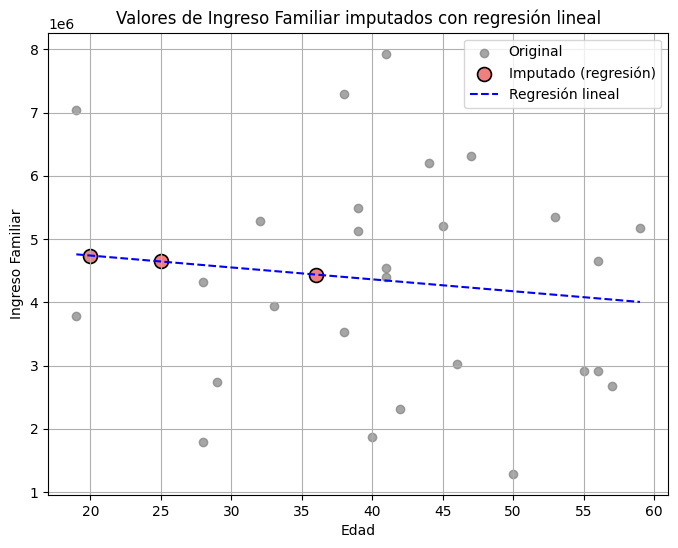

Valores faltantes antes de imputar (df original):
3

Valores faltantes después de imputar (data_impute_regression):
Edad                  0
Promedio              4
Horas_estudio         4
Ingreso_familiar      0
Semestres_cursados    0
dtype: int64


In [14]:
from sklearn.linear_model import LinearRegression

# Crear una copia del dataframe original para la imputación por regresión lineal
data_impute_regression = df.copy()

# Separar datos completos y faltantes para 'Ingreso_familiar'
mask_missing = data_impute_regression["Ingreso_familiar"].isnull()
X_train = data_impute_regression.loc[~mask_missing, ["Edad"]]
y_train = data_impute_regression.loc[~mask_missing, "Ingreso_familiar"]

X_missing = data_impute_regression.loc[mask_missing, ["Edad"]]

# Crear y entrenar el modelo de regresión lineal
reg = LinearRegression()
reg.fit(X_train, y_train)

# Rellenar los valores faltantes en 'Ingreso_familiar' con las predicciones del modelo
data_impute_regression.loc[mask_missing, "Ingreso_familiar"] = reg.predict(X_missing)

# --- Visualización de los datos originales con valores faltantes ---
plt.figure(figsize=(8,6))
plt.scatter(df["Edad"], df["Ingreso_familiar"],
            color="gray", alpha=0.7, label="Datos disponibles")
# Representar los valores que eran faltantes en el df original
plt.scatter(df.loc[df["Ingreso_familiar"].isnull(), "Edad"],
            [df["Ingreso_familiar"].min()]*df["Ingreso_familiar"].isnull().sum(), # Ajustar la altura para mejor visibilidad
            marker="x", color="black", s=100, label="Valores originalmente faltantes")

plt.xlabel("Edad")
plt.ylabel("Ingreso Familiar")
plt.title("Datos con valores faltantes originales en Ingreso Familiar")
plt.legend()
plt.grid(True)
plt.show()

# --- Visualización de los valores imputados con regresión lineal ---
plt.figure(figsize=(8,6))
plt.scatter(data_impute_regression.loc[~mask_missing, "Edad"],
            data_impute_regression.loc[~mask_missing, "Ingreso_familiar"],
            color="gray", alpha=0.7, label="Original")
plt.scatter(data_impute_regression.loc[mask_missing, "Edad"],
            data_impute_regression.loc[mask_missing, "Ingreso_familiar"],
            color="lightcoral", edgecolors="black", linewidths=1.2,
            s=100, label="Imputado (regresión)")

x_line = np.linspace(df["Edad"].min(), df["Edad"].max(), 100).reshape(-1,1)
y_line = reg.predict(x_line)
plt.plot(x_line, y_line, color="blue", linestyle="--", label="Regresión lineal")

plt.xlabel("Edad")
plt.ylabel("Ingreso Familiar")
plt.title("Valores de Ingreso Familiar imputados con regresión lineal")
plt.legend()
plt.grid(True)
plt.show()

# -------- Verificación --------
print("Valores faltantes antes de imputar (df original):")
print(df["Ingreso_familiar"].isnull().sum())

print("\nValores faltantes después de imputar (data_impute_regression):")
print(data_impute_regression.isnull().sum())

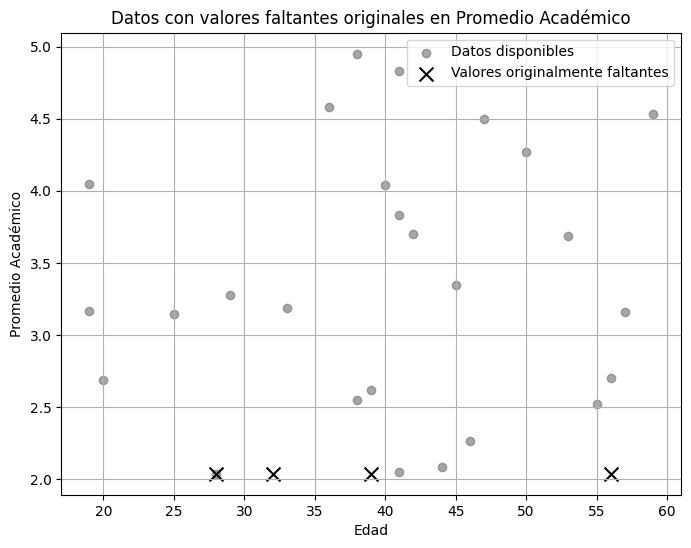

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


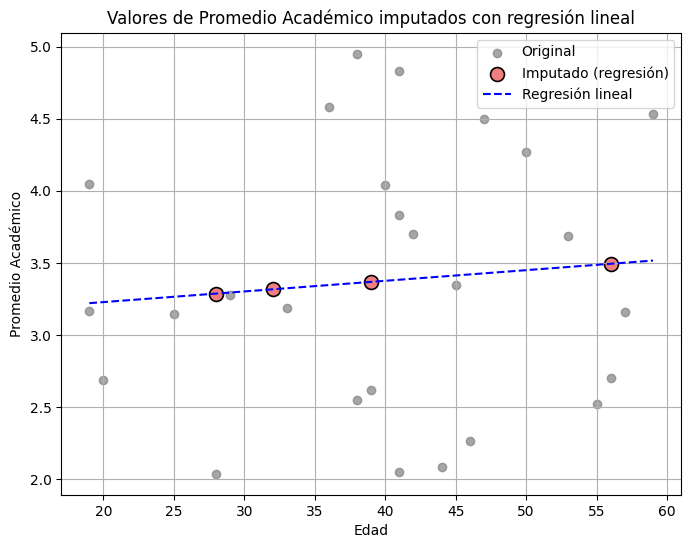

Valores faltantes antes de imputar (df original):
4

Valores faltantes después de imputar (data_impute_promedio):
Edad                  0
Promedio              0
Horas_estudio         4
Ingreso_familiar      3
Semestres_cursados    0
dtype: int64


In [15]:
# Crear una copia del dataframe original para la imputación por regresión lineal
data_impute_promedio = df.copy()

# Separar datos completos y faltantes para 'Promedio'
mask_missing_promedio = data_impute_promedio["Promedio"].isnull()
X_train_promedio = data_impute_promedio.loc[~mask_missing_promedio, ["Edad"]]
y_train_promedio = data_impute_promedio.loc[~mask_missing_promedio, "Promedio"]

X_missing_promedio = data_impute_promedio.loc[mask_missing_promedio, ["Edad"]]

# Crear y entrenar el modelo de regresión lineal
reg_promedio = LinearRegression()
reg_promedio.fit(X_train_promedio, y_train_promedio)

# Rellenar los valores faltantes en 'Promedio' con las predicciones del modelo
data_impute_promedio.loc[mask_missing_promedio, "Promedio"] = reg_promedio.predict(X_missing_promedio)

# --- Visualización de los datos originales con valores faltantes ---
plt.figure(figsize=(8,6))
plt.scatter(df["Edad"], df["Promedio"],
            color="gray", alpha=0.7, label="Datos disponibles")
# Representar los valores que eran faltantes en el df original
plt.scatter(df.loc[df["Promedio"].isnull(), "Edad"],
            [df["Promedio"].min()]*df["Promedio"].isnull().sum(), # Ajustar la altura para mejor visibilidad
            marker="x", color="black", s=100, label="Valores originalmente faltantes")

plt.xlabel("Edad")
plt.ylabel("Promedio Académico")
plt.title("Datos con valores faltantes originales en Promedio Académico")
plt.legend()
plt.grid(True)
plt.show()

# --- Visualización de los valores imputados con regresión lineal ---
plt.figure(figsize=(8,6))
plt.scatter(data_impute_promedio.loc[~mask_missing_promedio, "Edad"],
            data_impute_promedio.loc[~mask_missing_promedio, "Promedio"],
            color="gray", alpha=0.7, label="Original")
plt.scatter(data_impute_promedio.loc[mask_missing_promedio, "Edad"],
            data_impute_promedio.loc[mask_missing_promedio, "Promedio"],
            color="lightcoral", edgecolors="black", linewidths=1.2,
            s=100, label="Imputado (regresión)")

x_line_promedio = np.linspace(df["Edad"].min(), df["Edad"].max(), 100).reshape(-1,1)
y_line_promedio = reg_promedio.predict(x_line_promedio)
plt.plot(x_line_promedio, y_line_promedio, color="blue", linestyle="--", label="Regresión lineal")

plt.xlabel("Edad")
plt.ylabel("Promedio Académico")
plt.title("Valores de Promedio Académico imputados con regresión lineal")
plt.legend()
plt.grid(True)
plt.show()

# -------- Verificación --------
print("Valores faltantes antes de imputar (df original):")
print(df["Promedio"].isnull().sum())

print("\nValores faltantes después de imputar (data_impute_promedio):")
print(data_impute_promedio.isnull().sum())

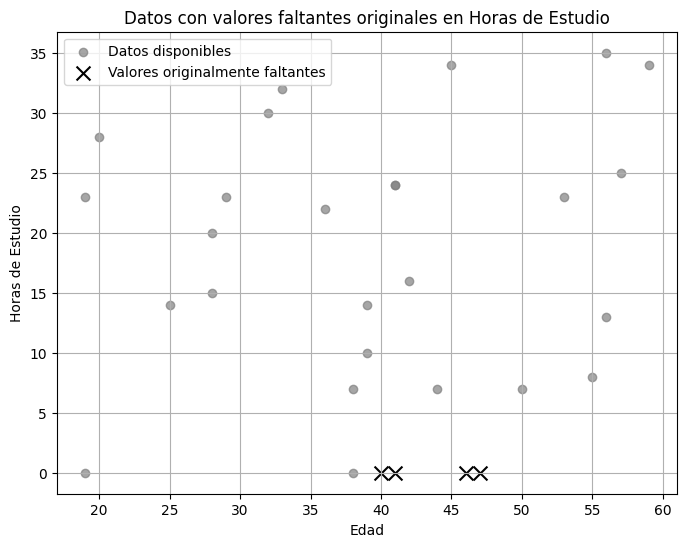

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


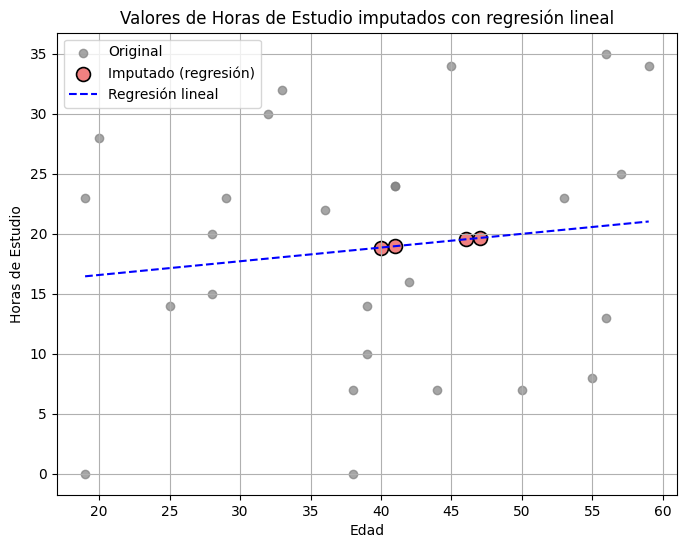

Valores faltantes antes de imputar (df original):
4

Valores faltantes después de imputar (data_impute_horas_estudio):
Edad                  0
Promedio              4
Horas_estudio         0
Ingreso_familiar      3
Semestres_cursados    0
dtype: int64


In [16]:
# Crear una copia del dataframe original para la imputación por regresión lineal
data_impute_horas_estudio = df.copy()

# Separar datos completos y faltantes para 'Horas_estudio'
mask_missing_horas_estudio = data_impute_horas_estudio["Horas_estudio"].isnull()
X_train_horas_estudio = data_impute_horas_estudio.loc[~mask_missing_horas_estudio, ["Edad"]]
y_train_horas_estudio = data_impute_horas_estudio.loc[~mask_missing_horas_estudio, "Horas_estudio"]

X_missing_horas_estudio = data_impute_horas_estudio.loc[mask_missing_horas_estudio, ["Edad"]]

# Crear y entrenar el modelo de regresión lineal
reg_horas_estudio = LinearRegression()
reg_horas_estudio.fit(X_train_horas_estudio, y_train_horas_estudio)

# Rellenar los valores faltantes en 'Horas_estudio' con las predicciones del modelo
data_impute_horas_estudio.loc[mask_missing_horas_estudio, "Horas_estudio"] = reg_horas_estudio.predict(X_missing_horas_estudio)

# --- Visualización de los datos originales con valores faltantes ---
plt.figure(figsize=(8,6))
plt.scatter(df["Edad"], df["Horas_estudio"],
            color="gray", alpha=0.7, label="Datos disponibles")
# Representar los valores que eran faltantes en el df original
plt.scatter(df.loc[df["Horas_estudio"].isnull(), "Edad"],
            [df["Horas_estudio"].min()]*df["Horas_estudio"].isnull().sum(), # Ajustar la altura para mejor visibilidad
            marker="x", color="black", s=100, label="Valores originalmente faltantes")

plt.xlabel("Edad")
plt.ylabel("Horas de Estudio")
plt.title("Datos con valores faltantes originales en Horas de Estudio")
plt.legend()
plt.grid(True)
plt.show()

# --- Visualización de los valores imputados con regresión lineal ---
plt.figure(figsize=(8,6))
plt.scatter(data_impute_horas_estudio.loc[~mask_missing_horas_estudio, "Edad"],
            data_impute_horas_estudio.loc[~mask_missing_horas_estudio, "Horas_estudio"],
            color="gray", alpha=0.7, label="Original")
plt.scatter(data_impute_horas_estudio.loc[mask_missing_horas_estudio, "Edad"],
            data_impute_horas_estudio.loc[mask_missing_horas_estudio, "Horas_estudio"],
            color="lightcoral", edgecolors="black", linewidths=1.2,
            s=100, label="Imputado (regresión)")

x_line_horas_estudio = np.linspace(df["Edad"].min(), df["Edad"].max(), 100).reshape(-1,1)
y_line_horas_estudio = reg_horas_estudio.predict(x_line_horas_estudio)
plt.plot(x_line_horas_estudio, y_line_horas_estudio, color="blue", linestyle="--", label="Regresión lineal")

plt.xlabel("Edad")
plt.ylabel("Horas de Estudio")
plt.title("Valores de Horas de Estudio imputados con regresión lineal")
plt.legend()
plt.grid(True)
plt.show()

# -------- Verificación --------
print("Valores faltantes antes de imputar (df original):")
print(df["Horas_estudio"].isnull().sum())

print("\nValores faltantes después de imputar (data_impute_horas_estudio):")
print(data_impute_horas_estudio.isnull().sum())

In [17]:
from sklearn.metrics import mean_absolute_error

# Helper function to introduce synthetic missingness and evaluate imputation
def evaluate_imputation_mae(original_df, target_column, predictor_column, missing_percentage=0.2, knn_neighbors=3):
    print(f"--- Evaluando '{target_column}' ---")

    # Make a copy to avoid modifying the original df
    df_eval = original_df.copy()

    # Identify non-missing values in the target column
    non_missing_indices = df_eval[df_eval[target_column].notna()].index
    num_to_hide = int(len(non_missing_indices) * missing_percentage)

    # Randomly select indices to hide (create synthetic missingness)
    np.random.seed(42) # for reproducibility
    indices_to_hide = np.random.choice(non_missing_indices, num_to_hide, replace=False)

    # Store true values for the hidden data
    true_values = df_eval.loc[indices_to_hide, target_column].copy()

    # Introduce synthetic missingness
    df_eval.loc[indices_to_hide, target_column] = np.nan

    # --- KNN Imputation ---
    print("Realizando Imputación KNN...")
    knn_imputer = KNNImputer(n_neighbors=knn_neighbors)
    # Fit and transform on the entire df_eval, including original and synthetic NaNs
    df_knn_imputed_full = pd.DataFrame(knn_imputer.fit_transform(df_eval), columns=df_eval.columns, index=df_eval.index)

    # Extract KNN imputed values only for the synthetic NaNs for MAE calculation
    knn_imputed_values = df_knn_imputed_full.loc[indices_to_hide, target_column]
    mae_knn = mean_absolute_error(true_values, knn_imputed_values)
    print(f"MAE para Imputación KNN ('{target_column}'): {mae_knn:.4f}")

    # --- Linear Regression Imputation ---
    print("Realizando Imputación por Regresión Lineal...")

    # Prepare data for LR: X_train, y_train must exclude any NaNs in target or predictor
    mask_lr_train = df_eval[target_column].notna() & df_eval[predictor_column].notna()
    X_train_lr = df_eval.loc[mask_lr_train, [predictor_column]]
    y_train_lr = df_eval.loc[mask_lr_train, target_column]

    # X_predict for LR must include all rows where target is NaN (original + synthetic) AND predictor is not NaN
    mask_lr_predict = df_eval[target_column].isna() & df_eval[predictor_column].notna()
    X_predict_lr = df_eval.loc[mask_lr_predict, [predictor_column]]

    mae_lr = np.nan # Default to NaN if LR can't be performed

    if not X_train_lr.empty and not X_predict_lr.empty:
        lr_model = LinearRegression()
        lr_model.fit(X_train_lr, y_train_lr)

        df_lr_imputed_full = df_eval.copy()
        df_lr_imputed_full.loc[mask_lr_predict, target_column] = lr_model.predict(X_predict_lr)

        # Extract LR imputed values only for the synthetic NaNs for MAE calculation
        lr_imputed_values = df_lr_imputed_full.loc[indices_to_hide, target_column]
        mae_lr = mean_absolute_error(true_values, lr_imputed_values)
        print(f"MAE para Imputación por Regresión Lineal ('{target_column}'): {mae_lr:.4f}")
    else:
        print(f"No hay suficientes datos para realizar la imputación por Regresión Lineal para '{target_column}' (después de crear valores faltantes sintéticos y manejar los NaNs originales).")

    print("-" * 40)
    return mae_knn, mae_lr

# Define the target columns for evaluation and the predictor column
target_columns_to_evaluate = ['Ingreso_familiar', 'Promedio', 'Horas_estudio']
predictor_for_lr = 'Edad' # Based on previous usage

mae_results = {}
for col in target_columns_to_evaluate:
    mae_knn, mae_lr = evaluate_imputation_mae(df, col, predictor_for_lr)
    mae_results[col] = {'KNN_MAE': mae_knn, 'LR_MAE': mae_lr}

print("\n### Resumen de Puntuaciones MAE ###")
for col, maes in mae_results.items():
    print(f"  '{col}':")
    print(f"    MAE KNN: {maes['KNN_MAE']:.4f}")
    print(f"    MAE Regresión Lineal: {maes['LR_MAE']:.4f}")

--- Evaluando 'Ingreso_familiar' ---
Realizando Imputación KNN...
MAE para Imputación KNN ('Ingreso_familiar'): 2233410.8667
Realizando Imputación por Regresión Lineal...
MAE para Imputación por Regresión Lineal ('Ingreso_familiar'): 2117350.3073
----------------------------------------
--- Evaluando 'Promedio' ---
Realizando Imputación KNN...
MAE para Imputación KNN ('Promedio'): 0.5673
Realizando Imputación por Regresión Lineal...
MAE para Imputación por Regresión Lineal ('Promedio'): 0.3755
----------------------------------------
--- Evaluando 'Horas_estudio' ---
Realizando Imputación KNN...
MAE para Imputación KNN ('Horas_estudio'): 10.1333
Realizando Imputación por Regresión Lineal...
MAE para Imputación por Regresión Lineal ('Horas_estudio'): 12.2728
----------------------------------------

### Resumen de Puntuaciones MAE ###
  'Ingreso_familiar':
    MAE KNN: 2233410.8667
    MAE Regresión Lineal: 2117350.3073
  'Promedio':
    MAE KNN: 0.5673
    MAE Regresión Lineal: 0.3755


/tmp/ipykernel_4122/1285894221.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metodo', y='MAE', data=mae_df[mae_df['Variable'] == var], palette='viridis')


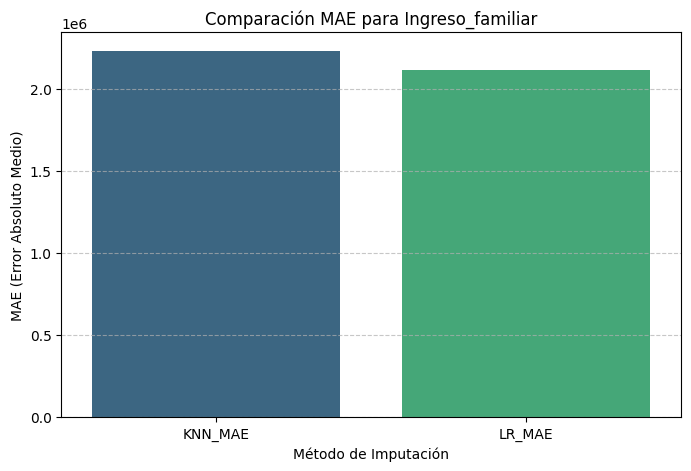

/tmp/ipykernel_4122/1285894221.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metodo', y='MAE', data=mae_df[mae_df['Variable'] == var], palette='viridis')


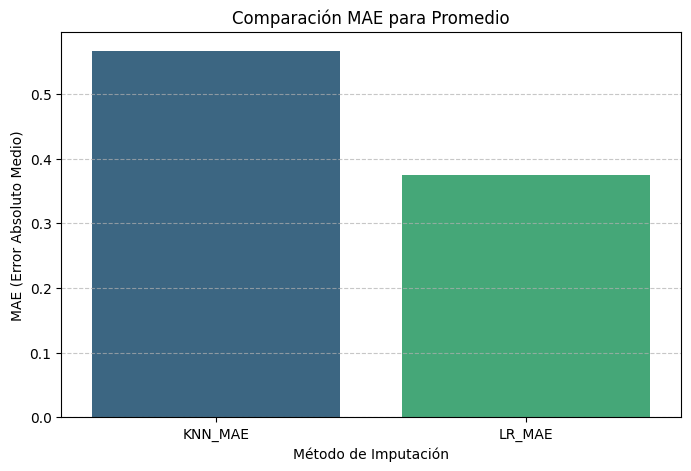

/tmp/ipykernel_4122/1285894221.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metodo', y='MAE', data=mae_df[mae_df['Variable'] == var], palette='viridis')


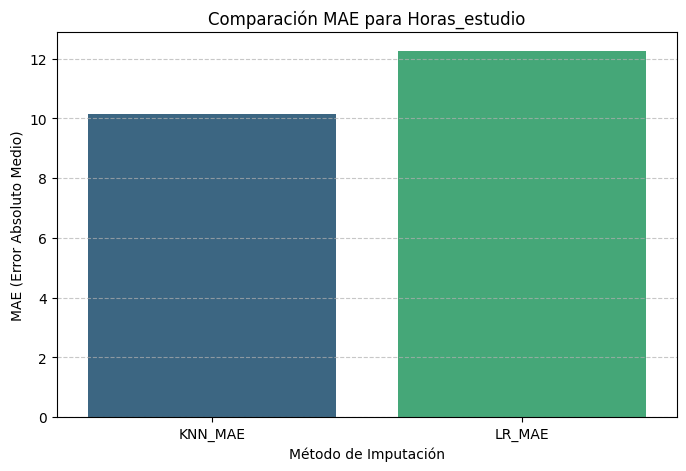

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convertir los resultados MAE a un DataFrame para facilitar la visualización
mae_df_time_series = pd.DataFrame(mae_results_time_series).T # Transponer para que las variables sean el índice
mae_df_time_series = mae_df_time_series.stack().reset_index() # Apilar para tener 'Metodo' como columna
mae_df_time_series.columns = ['Variable', 'Metodo', 'MAE']

# Obtener las variables únicas
variables_time_series = mae_df_time_series['Variable'].unique()

for var in variables_time_series:
    plt.figure(figsize=(8, 5)) # Tamaño de figura para cada gráfico
    sns.barplot(x='Metodo', y='MAE', data=mae_df_time_series[mae_df_time_series['Variable'] == var], palette='viridis')
    plt.title(f'Comparación MAE para {var}')
    plt.xlabel('Método de Imputación')
    plt.ylabel('MAE (Error Absoluto Medio)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

Comparando gráficamente en cada uno de los métodos de imputación se influye que el método KNN conserva mucho más la naturaleza de los datos, sin embargo, al comparar el MAE se evidencia que el método de imputación por regresión tiene un menor error para las variables "promedio" e "ingreso familiar", pero los valores del MAE son muy altos para "ingreso familiar" y "horas de estudio" por lo que se podría inferir que no son los mejores métodos de imputación para esas variables.

#Ejercicio 6: Imputación con LOCF y NOCB

In [36]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 30

df = pd.DataFrame({
    'Fecha': pd.date_range(start='2023-01-01', periods=n, freq='D'),
    'Ventas': np.round(np.random.uniform(100, 500, n), 2),
    'Inventario': np.random.randint(10, 100, n),
    'Clientes': np.random.randint(1, 50, n)
})

# Introducción de valores faltantes
df.loc[[3, 4, 5, 12, 13], 'Ventas'] = np.nan
df.loc[[7, 8, 20], 'Inventario'] = np.nan
df.loc[[1, 2, 18, 19], 'Clientes'] = np.nan
df = df.sort_values('Fecha').reset_index(drop=True)

In [37]:
# Imputación con LOCF (Last Observation Carried Forward)
df_locf = df.ffill()

# Imputación con NOCB (Next Observation Carried Backward)
df_nocb = df.bfill()

print("DataFrame con imputación LOCF (primeras 5 filas):")
display(df_locf.head())
print("\nDataFrame con imputación NOCB (primeras 5 filas):")
display(df_nocb.head())


DataFrame con imputación LOCF (primeras 5 filas):


,Fecha,Ventas,Inventario,Clientes
0,2023-01-01,249.82,60.0,29.0
1,2023-01-02,480.29,16.0,29.0
2,2023-01-03,392.80,30.0,29.0
3,2023-01-04,392.80,82.0,44.0
4,2023-01-05,392.80,48.0,34.0



DataFrame con imputación NOCB (primeras 5 filas):


,Fecha,Ventas,Inventario,Clientes
0,2023-01-01,249.82,60.0,29.0
1,2023-01-02,480.29,16.0,44.0
2,2023-01-03,392.80,30.0,44.0
3,2023-01-04,123.23,82.0,44.0
4,2023-01-05,123.23,48.0,34.0


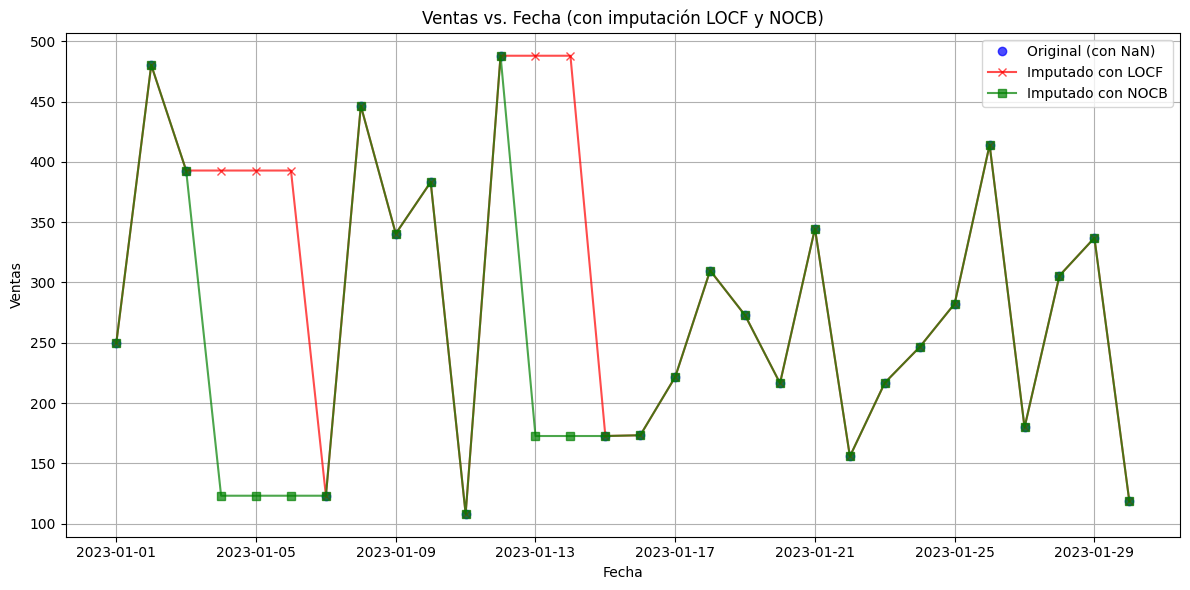

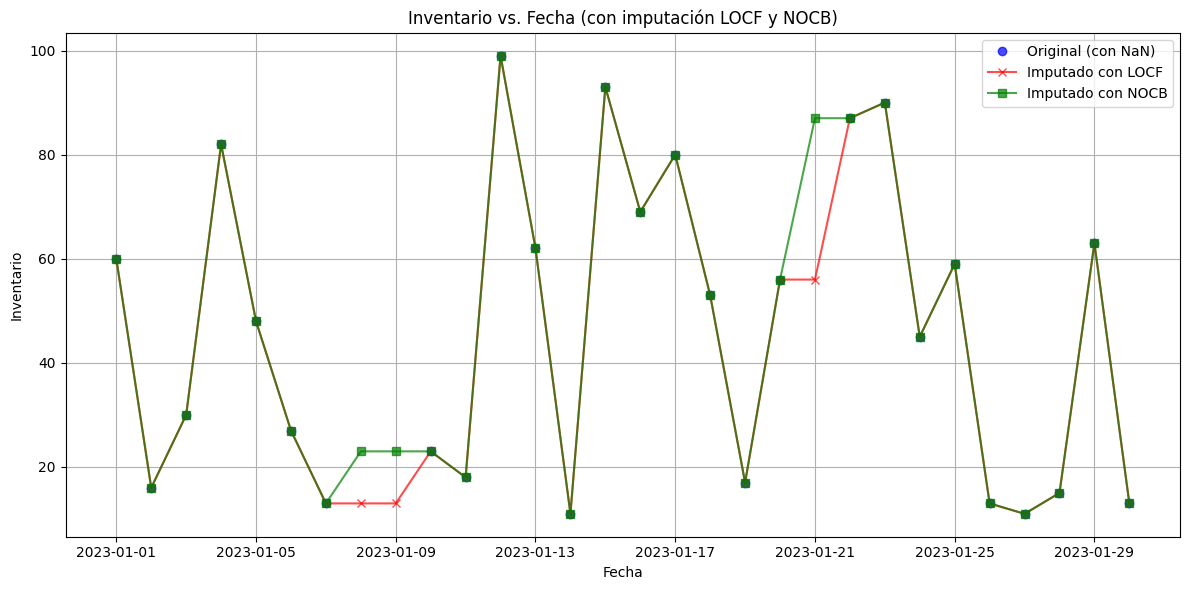

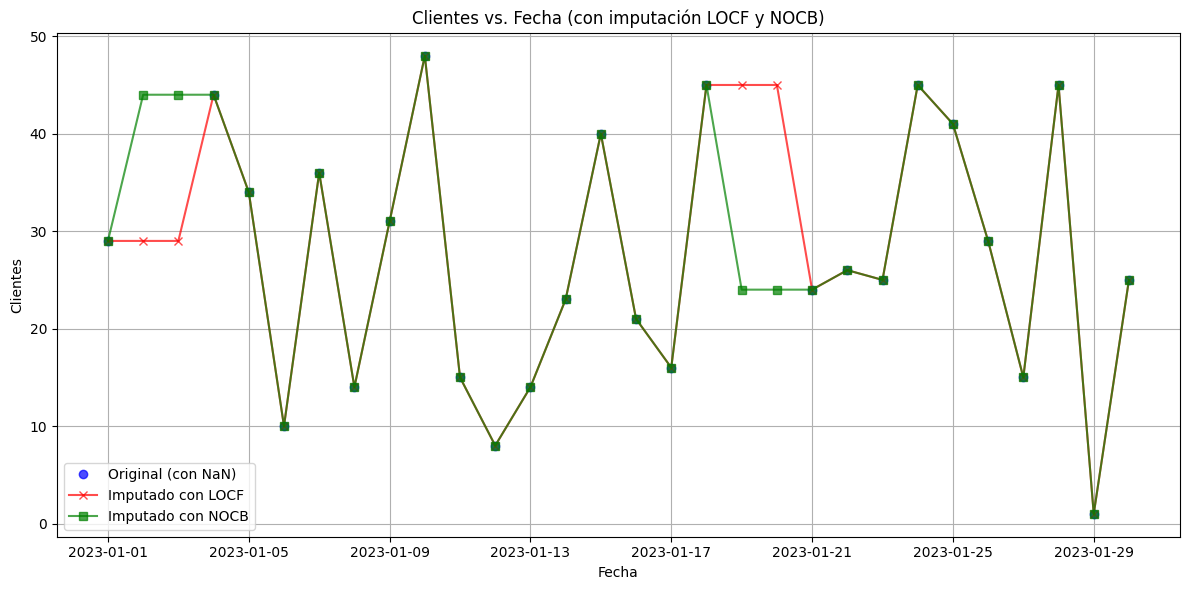

In [38]:
import matplotlib.pyplot as plt

# Visualización para 'Ventas'
plt.figure(figsize=(12, 6))
plt.plot(df['Fecha'], df['Ventas'], 'o', label='Original (con NaN)', color='blue', alpha=0.7)
plt.plot(df['Fecha'], df_locf['Ventas'], 'x-', label='Imputado con LOCF', color='red', alpha=0.7)
plt.plot(df['Fecha'], df_nocb['Ventas'], 's-', label='Imputado con NOCB', color='green', alpha=0.7)
plt.title('Ventas vs. Fecha (con imputación LOCF y NOCB)')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Visualización para 'Inventario'
plt.figure(figsize=(12, 6))
plt.plot(df['Fecha'], df['Inventario'], 'o', label='Original (con NaN)', color='blue', alpha=0.7)
plt.plot(df['Fecha'], df_locf['Inventario'], 'x-', label='Imputado con LOCF', color='red', alpha=0.7)
plt.plot(df['Fecha'], df_nocb['Inventario'], 's-', label='Imputado con NOCB', color='green', alpha=0.7)
plt.title('Inventario vs. Fecha (con imputación LOCF y NOCB)')
plt.xlabel('Fecha')
plt.ylabel('Inventario')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Visualización para 'Clientes'
plt.figure(figsize=(12, 6))
plt.plot(df['Fecha'], df['Clientes'], 'o', label='Original (con NaN)', color='blue', alpha=0.7)
plt.plot(df['Fecha'], df_locf['Clientes'], 'x-', label='Imputado con LOCF', color='red', alpha=0.7)
plt.plot(df['Fecha'], df_nocb['Clientes'], 's-', label='Imputado con NOCB', color='green', alpha=0.7)
plt.title('Clientes vs. Fecha (con imputación LOCF y NOCB)')
plt.xlabel('Fecha')
plt.ylabel('Clientes')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

- ¿Qué variables presentan datos faltantes consecutivos?

  R/= Las variables "ventas", "inventario" y "clientes" presentan datos faltantes consecutivos. Siendo "ventas" la que mayor cantidad de datos faltantes y consecutivos tiene.
- ¿Por qué este tipo de patrón es relevante en series temporales?

  R/= Porque evidencian una falla en la medición; falla que se puede deber al instrumento de medición
- ¿Qué implicaciones tiene el orden de los datos para este tipo de imputación?

  R/= Las implicaciones son que en el caso donde el dato last o next sea un outlier o un error de medición, este se repetirá de manera consecutiva hasta "llenar" los espacios con los datos faltantes.

¿Cuál método consideras más apropiado para este caso y por qué?

In [40]:
from sklearn.metrics import mean_absolute_error

def evaluate_locf_nocb_mae(original_df, target_column, missing_percentage=0.2):
    print(f"--- Evaluando '{target_column}' para LOCF y NOCB ---")

    df_eval = original_df.copy()

    # Identify non-missing values in the target column
    non_missing_original_indices = df_eval[df_eval[target_column].notna()].index
    num_to_hide = int(len(non_missing_original_indices) * missing_percentage)

    # Randomly select indices to hide (create synthetic missingness)
    np.random.seed(42) # for reproducibility
    indices_to_hide = np.random.choice(non_missing_original_indices, num_to_hide, replace=False)

    # Store true values for the hidden data
    true_values = df_eval.loc[indices_to_hide, target_column].copy()

    # Introduce synthetic missingness
    df_eval.loc[indices_to_hide, target_column] = np.nan

    # --- LOCF Imputation ---
    print("Realizando Imputación LOCF...")
    df_locf_imputed = df_eval.ffill()

    # Filter out any indices_to_hide where imputation was not possible (e.g., leading NaNs)
    valid_locf_imputed_indices = indices_to_hide[df_locf_imputed.loc[indices_to_hide, target_column].notna()]
    if len(valid_locf_imputed_indices) == 0:
        mae_locf = np.nan # No valid imputed values to compare
        print(f"No hay suficientes valores imputados para calcular MAE LOCF para '{target_column}'.")
    else:
        locf_imputed_values = df_locf_imputed.loc[valid_locf_imputed_indices, target_column]
        true_values_locf = true_values.loc[valid_locf_imputed_indices]
        mae_locf = mean_absolute_error(true_values_locf, locf_imputed_values)
        print(f"MAE para Imputación LOCF ('{target_column}'): {mae_locf:.4f}")


    # --- NOCB Imputation ---
    print("Realizando Imputación NOCB...")
    df_nocb_imputed = df_eval.bfill()

    # Filter out any indices_to_hide where imputation was not possible (e.g., trailing NaNs)
    valid_nocb_imputed_indices = indices_to_hide[df_nocb_imputed.loc[indices_to_hide, target_column].notna()]
    if len(valid_nocb_imputed_indices) == 0:
        mae_nocb = np.nan # No valid imputed values to compare
        print(f"No hay suficientes valores imputados para calcular MAE NOCB para '{target_column}'.")
    else:
        nocb_imputed_values = df_nocb_imputed.loc[valid_nocb_imputed_indices, target_column]
        true_values_nocb = true_values.loc[valid_nocb_imputed_indices]
        mae_nocb = mean_absolute_error(true_values_nocb, nocb_imputed_values)
        print(f"MAE para Imputación NOCB ('{target_column}'): {mae_nocb:.4f}")

    print("-" * 40)
    return mae_locf, mae_nocb

# Define the target columns for evaluation
target_columns_time_series = ['Ventas', 'Inventario', 'Clientes']

mae_results_time_series = {}
for col in target_columns_time_series:
    mae_locf, mae_nocb = evaluate_locf_nocb_mae(df, col)
    mae_results_time_series[col] = {'LOCF_MAE': mae_locf, 'NOCB_MAE': mae_nocb}

print("\n### Resumen de Puntuaciones MAE (LOCF vs NOCB) ###")
for col, maes in mae_results_time_series.items():
    print(f"  '{col}':")
    print(f"    MAE LOCF: {maes['LOCF_MAE']:.4f}")
    print(f"    MAE NOCB: {maes['NOCB_MAE']:.4f}")

--- Evaluando 'Ventas' para LOCF y NOCB ---
Realizando Imputación LOCF...
MAE para Imputación LOCF ('Ventas'): 162.0725
Realizando Imputación NOCB...
MAE para Imputación NOCB ('Ventas'): 182.6700
----------------------------------------
--- Evaluando 'Inventario' para LOCF y NOCB ---
Realizando Imputación LOCF...
MAE para Imputación LOCF ('Inventario'): 29.7500
Realizando Imputación NOCB...
MAE para Imputación NOCB ('Inventario'): 36.4000
----------------------------------------
--- Evaluando 'Clientes' para LOCF y NOCB ---
Realizando Imputación LOCF...
MAE para Imputación LOCF ('Clientes'): 26.7500
Realizando Imputación NOCB...
MAE para Imputación NOCB ('Clientes'): 13.0000
----------------------------------------

### Resumen de Puntuaciones MAE (LOCF vs NOCB) ###
  'Ventas':
    MAE LOCF: 162.0725
    MAE NOCB: 182.6700
  'Inventario':
    MAE LOCF: 29.7500
    MAE NOCB: 36.4000
  'Clientes':
    MAE LOCF: 26.7500
    MAE NOCB: 13.0000


Si analizamos el MAE de cada uno de los métodos, para las varibes "ventas" e "inventario" funciona más LOCF, mientras que para "clientes" funciona más NOCB, por lo que se puede influir que dependiendo de la variable conviene usar uno u otro método de imputación. Sin embargo, la idea de la imputación es que el error no sea alto para así no alterar la naturaleza del set datos, entonces no conviene usar ninguno de los dos porque el valor absoluto medio da muy alto (pensando en que se prefieren valores cercanos a cero).